## **Introduction to Investment Analytics**

You already learned how to interpret mean of return and standard deviation as the risk measure. Now lets go straight to skewness and kurtosis.

##### **Skewness – Asymmetry of Returns**
What it is: Measures whether the return distribution leans more to the left (more losses) or right (more gains).

Range & Interpretation:
- 0 = perfectly symmetrical (like a bell curve).
- Positive skew (>0) = long right tail → occasional big gains.
- Negative skew (<0) = long left tail → occasional big losses.

Investment insight:
- A negatively skewed stock tends to show small daily gains but occasionally suffers big drops (example: many growth stocks or high-beta tech stocks).
- A positively skewed stock may have frequent small losses but sometimes delivers big wins (like a lottery ticket stock).


##### **Kurtosis – Thickness of Tails / Outlier Risk**
What it is: Measures how fat or thin the tails of the return distribution are compared to the normal distribution (which has kurtosis = 3).

Range & Interpretation:
- Kurtosis ≈ 3 = normal tail thickness (Gaussian).
- Kurtosis > 3 (leptokurtic) = fat tails → more frequent extreme returns (gains/losses).
- Kurtosis < 3 (platykurtic) = thin tails → less risk of extreme returns.

Investment insight:
- A stock with high kurtosis is more prone to sudden, unexpected shocks (crashes or rallies), even if daily volatility seems low.
- Fat tails mean higher downside and upside tail risks — important for risk managers, option traders, and hedge funds.

## ***Different asset, different characteristics!***

#### Install libraries, import the library, load the data.

In [3]:
!pip install pandas numpy matplotlib seaborn scipy

# What each package does:
## pandas → Data handling (DataFrame, time series, returns, covariance)
## numpy → Numerical computation (arrays, matrix math, np.dot, sqrt)
## matplotlib → Basic plotting (histogram, line chart, portfolio visuals)
## seaborn → Statistical visualization (enhanced plots, distribution curves)
## scipy → Statistical functions (normal distribution, hypothesis testing)

zsh:1: command not found: pip


In [5]:
# Load the CSV, parse the first column as dates, and set it as the index

import pandas as pd

df = pd.read_csv('rba tutorial 1.1.csv', parse_dates=[0]) #Look at the first column of the CSV, interpret its values as dates
df.set_index(df.columns[0], inplace=True) # # Makes the first column (which contains dates) the DataFrame’s index
df.sort_index(inplace=True)    # Sorts the rows by date in ascending order

# Check the data
df.head()


/var/folders/vr/z8bvnfg517g3fln2549b70sc0000gn/T/ipykernel_28446/2640706002.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('rba tutorial 1.1.csv', parse_dates=[0]) #Look at the first column of the CSV, interpret its values as dates


,btc,nifty_india,my_ace,my10,pbb,fbmklci
Date,,,,,,
2016-04-26,467.42,7962.6499,5672.7002,100.974,2.738766,1692.5000
2016-04-27,445.38,7979.8999,5672.9702,100.503,2.727136,1692.3400
2016-04-28,449.14,7847.2500,5607.1602,100.269,2.718414,1674.7600
2016-04-29,456.53,7849.7998,5617.0898,100.191,2.718414,1672.7200
2016-05-03,450.61,7747.0000,5618.6401,100.580,2.698062,1651.4399


### ***Descriptive statistics as a first step to risk profiling***

In [6]:
import numpy as np

# Compute daily (or periodic) returns
returns = np.log(df).diff()                             # Calculate percentage returns for each column

# Drop the first row since it will contain NaN values (no previous data for first observation)
returns.dropna(inplace=True)

# Calculate descriptive statistics of returns
desc_stats = pd.DataFrame({
    'mean': returns.mean(),                                  # Average return
    'median': returns.median(),                              # Median return
    'min': returns.min(),                                    # Lowest return
    'max': returns.max(),                                    # Highest return
    'std': returns.std(),                                    # Standard deviation (volatility)
    'skewness': returns.skew(),                              # Skewness (asymmetry)
    'kurtosis': returns.kurtosis()                           # Kurtosis (fat tails or peakedness)
})

# Display the descriptive statistics of returns
print(desc_stats.round(4))                                   # Round for readability

               mean  median     min     max     std  skewness  kurtosis
btc          0.0026  0.0022 -0.4940  0.2384  0.0462   -0.8923   11.6205
nifty_india  0.0005  0.0008 -0.1390  0.0840  0.0108   -1.2720   21.6381
my_ace      -0.0001  0.0005 -0.1547  0.1033  0.0155   -0.8913   13.6324
my10         0.0000  0.0000 -0.1358  0.1022  0.0058   -3.8858  267.8188
pbb          0.0002  0.0000 -0.0654  0.1171  0.0115    1.7815   19.3312
fbmklci     -0.0000 -0.0001 -0.0540  0.0663  0.0073   -0.3088    9.2564


### ***Correlation Matrix***

In [7]:
# Compute Pearson correlation matrix for returns
correlation_matrix = returns.corr()

# Display matrix (optional)
correlation_matrix.round(3)


,btc,nifty_india,my_ace,my10,pbb,fbmklci
btc,1.000,0.077,0.124,0.031,0.008,0.055
nifty_india,0.077,1.000,0.341,0.043,0.256,0.393
my_ace,0.124,0.341,1.000,0.041,0.269,0.558
my10,0.031,0.043,0.041,1.000,-0.035,0.038
pbb,0.008,0.256,0.269,-0.035,1.000,0.639
fbmklci,0.055,0.393,0.558,0.038,0.639,1.000


---
# **Introduction to Portfolio Construction**

## What Is a Portfolio?

A portfolio is simply a group of different investments like stocks, bonds, or crypto that you hold together. Think of it as a basket. Each item in the basket carries different levels of risk and return.

**The goal?**  
To combine these assets in a way that reduces risk while still aiming for good returns.

---

## Why Not Just Pick the Best Stock?

Because today’s top-performing stock might crash tomorrow.

Portfolio construction helps you **diversify**, which means spreading your money across multiple assets.  
That way, if one investment performs poorly, others may offset the loss so keeping your portfolio more stable.

---

## Start with Descriptive Statistics

Before building a portfolio, we first study the behavior of each asset over time using key statistical metrics:

| **Metric**      | **What It Tells You**                                 |
|------------------|--------------------------------------------------------|
| **Mean (%)**     | Average return per day                                |
| **Std Dev (%)**  | How "bumpy" or volatile the asset is                  |
| **Min / Max**    | Largest daily losses and gains                        |
| **Skewness**     | Whether gains or losses happen more often             |
| **Kurtosis**     | How often extreme jumps or crashes occur              |

These metrics help us understand the **character and risk profile** of each asset.

---

## Correlation: Do Assets Move Together?

We don’t just care how an asset behaves on its own — we ask:  
**Do they move in the same direction as each other?**

- **Positive correlation** (e.g., +0.80): They tend to rise and fall together  
- **Negative correlation** (e.g., -0.40): One rises when the other falls  
- **Zero correlation**: Their movements are unrelated

**Why this matters:**  
Assets with low or negative correlation are better together in a portfolio. One can cushion the impact when the other performs poorly.

---

## Combining Assets: The Power of Balance

By mixing:
- **High-return, high-risk assets** (like Bitcoin)
- **Stable, lower-return assets** (like bonds or large local stocks)

You can **smooth out the ups and downs**.  
This balance improves long-term stability without giving up all growth potential.

---

## Final Thought: It's About Trade-Offs

There’s **no perfect portfolio**.

- If you want **higher returns**, you’ll have to accept **higher risk**
- If you want **stability**, you’ll need to accept **lower returns**

Portfolio construction is about finding the **right mix** based on your goals, your time frame, and how much risk you’re comfortable taking.


- This handout is divided into learning zones.
- Some parts are meant to be adjusted by you.
- Some parts should not be adjusted unless you understand the structure of the dataset.

In [8]:
# Zone 1: Import libraries

# pandas is used to read and manage the dataset
import pandas as pd

# numpy is used for mathematical operations such as log returns and square root
import numpy as np

# matplotlib is used for plotting charts
import matplotlib.pyplot as plt

# norm is used to draw the theoretical normal distribution curve
from scipy.stats import norm

In [9]:
# Zone 2: Load and prepare the data

# Adjust this file name if your CSV file has a different name
file_name = "rba tutorial 1.2.csv"

# Read the CSV file
# parse_dates=[0] tells Python that the first column is a date column
# This is important because financial data must be arranged by date
df = pd.read_csv(file_name, parse_dates=[0])

# Set the first column as the index
# This makes the dataset a proper time series dataset
df.set_index(df.columns[0], inplace=True)

# Sort the data from oldest date to newest date
# This is necessary because return calculation depends on the previous price
df.sort_index(inplace=True)

# Preview the first five rows
# This allows us to check whether the data has been loaded correctly
df.head()

/var/folders/vr/z8bvnfg517g3fln2549b70sc0000gn/T/ipykernel_28446/1500224028.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(file_name, parse_dates=[0])


,gadang,pekat,myeg,ancom,kpj,fbmklci
Date,,,,,,
2024-02-21,0.405,0.405,0.763417,1.038189,1.598905,1552.40
2024-02-22,0.410,0.415,0.768311,1.038189,1.598905,1545.49
2024-02-23,0.395,0.415,0.768311,1.038189,1.598905,1549.11
2024-02-26,0.395,0.430,0.768311,1.028664,1.628153,1547.60
2024-02-27,0.390,0.445,0.768311,1.028664,1.628153,1558.80


In [10]:
# Zone 3: Clean column names

# Make column names consistent
# This avoids errors caused by capital letters or extra spaces
# Example: "FBMKLCI", "fbmklci" and " fbmklci " will be treated differently by Python
df.columns = df.columns.str.lower().str.strip()

In [11]:
# Zone 4: Calculate returns

# We create two types of returns because they serve different purposes. Simple returns are easier to interpret for investment performance. 
# Natural log returns are better for time series analysis and distribution modelling.

# Natural log return
# Formula: ln(Pt) minus ln(Pt minus 1)
# This is commonly used in econometrics, volatility analysis and normality checking
log_returns = np.log(df).diff().dropna()

# Simple return
# Formula: (Pt minus Pt minus 1) divided by Pt minus 1
# This is commonly used for portfolio performance and investor reporting
simple_returns = df.pct_change().dropna()

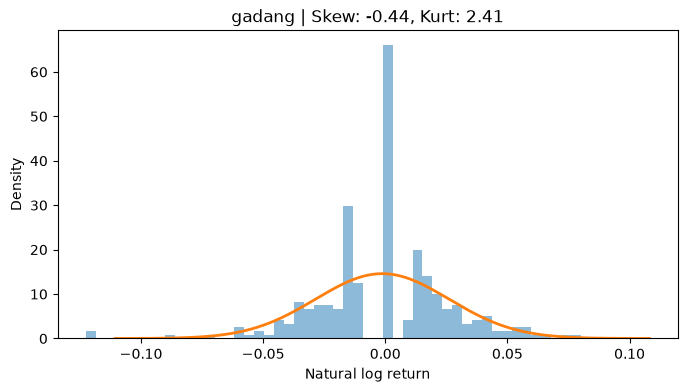

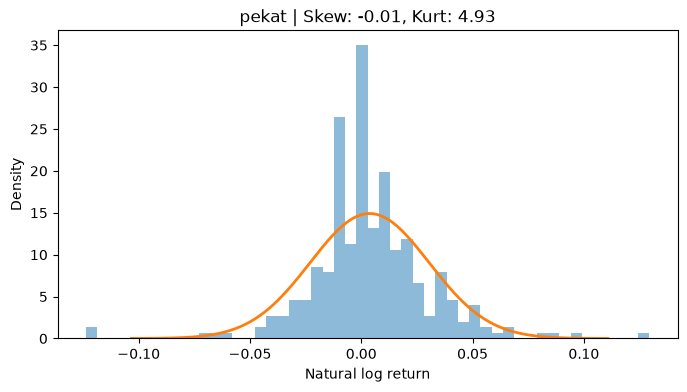

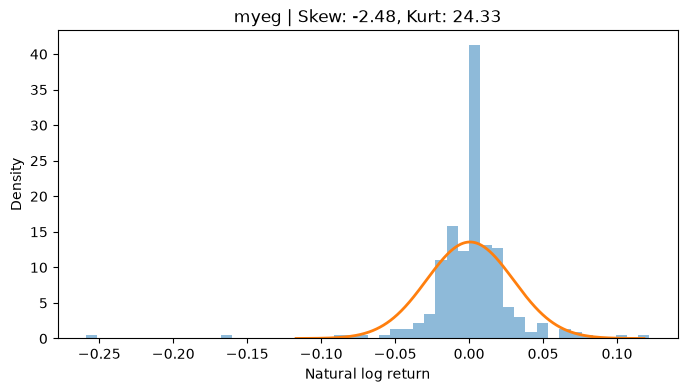

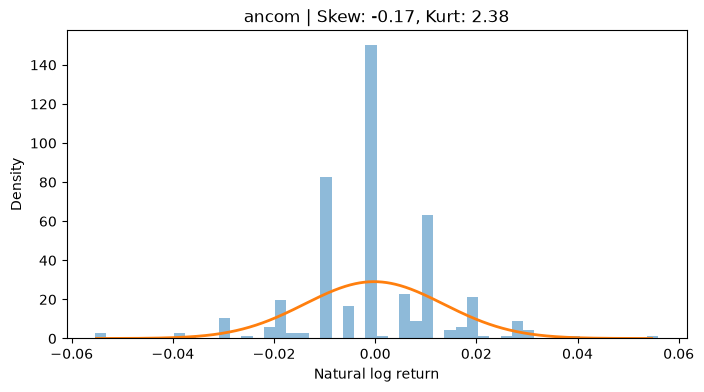

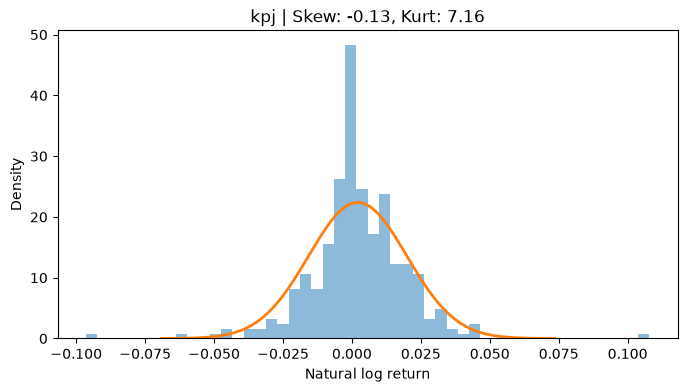

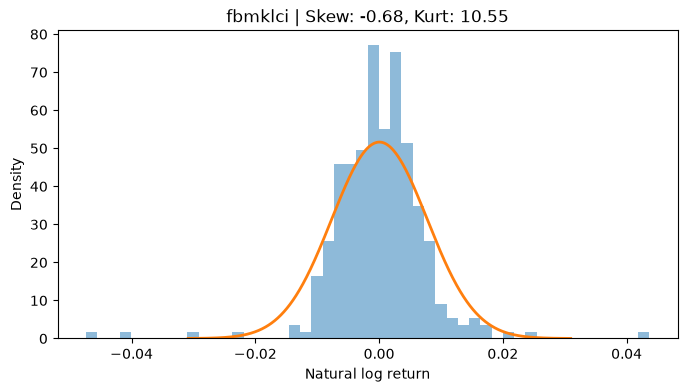

In [12]:
# Zone 5: Plot return distribution with normal curve

# Use log_returns here because we are checking the statistical behaviour of returns.

# Loop through each asset or index in the log return dataset
# We do this because each asset has its own return pattern, risk and distribution
for col in log_returns.columns:

    # Remove missing values
    # Missing values can cause errors in the mean, standard deviation and plot
    data = log_returns[col].dropna()

    # Calculate the average return and volatility
    # Mean shows the centre of the return distribution
    # Standard deviation shows how widely returns move around the mean
    mean = data.mean()
    std = data.std()

    # Create a smooth range of return values around the mean
    # Mean plus and minus 4 standard deviations covers most observations
    x = np.linspace(mean - 4 * std, mean + 4 * std, 1000)

    # Create the normal distribution curve
    # This shows how the returns would look if they were normally distributed
    y = norm.pdf(x, mean, std)

    # Plot the actual return distribution
    # The histogram shows the real behaviour of asset returns
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=50, density=True, alpha=0.5)

    # Add the normal curve for comparison
    # This helps us see whether actual returns follow the normal distribution assumption
    plt.plot(x, y, linewidth=2)

    # Show skewness and kurtosis in the title
    # Skewness shows whether returns lean to the left or right
    # Kurtosis shows whether returns have extreme tails
    plt.title(f"{col} | Skew: {data.skew():.2f}, Kurt: {data.kurtosis():.2f}")

    # Label the axes
    # Natural log return is shown on the horizontal axis
    # Density shows how concentrated the returns are
    plt.xlabel("Natural log return")
    plt.ylabel("Density")

    # Display the chart
    plt.show()

| Stock   |  Skew | Direction            | Kurtosis | Type               | Return Pattern                                           | Investor     |
| ------- | ----: | -------------------- | -------: | ------------------ | -------------------------------------------------------- | ------------ |
| GADANG  | -0.44 | Left skewed          |     2.41 | Leptokurtic        | Mild downside bias with some tail risk, but not extreme  | Risk Neutral |
| PEKAT   | -0.01 | Nearly symmetrical   |     4.93 | Leptokurtic        | Balanced average movement, but occasional large shocks   | Risk Neutral |
| MYEG    | -2.48 | Strongly left skewed |    24.33 | Highly leptokurtic | Severe downside tail risk, clear crash exposure          | Risk Taker   |
| ANCOM   | -0.17 | Slightly left skewed |     2.38 | Leptokurtic        | Mostly stable, with mild downside and moderate tail risk | Risk Neutral |
| KPJ     | -0.13 | Slightly left skewed |     7.16 | Highly leptokurtic | Calm most of the time, but exposed to sudden large moves | Risk Neutral |
| FBMKLCI | -0.68 | Left skewed          |    10.55 | Highly leptokurtic | Benchmark with negative tail risk and rare market shocks | Risk Averse  |


In [13]:
# Zone 6: Correlation matrix

# Use simple returns here because correlation is easier to interpret using normal percentage returns.
correlation_matrix = simple_returns.corr()

# Display the correlation matrix
print("Correlation Matrix Across Stocks:")
print(correlation_matrix.round(3))

Correlation Matrix Across Stocks:
         gadang  pekat   myeg  ancom    kpj  fbmklci
gadang    1.000  0.227  0.312  0.335  0.201    0.450
pekat     0.227  1.000  0.223  0.264  0.187    0.317
myeg      0.312  0.223  1.000  0.252  0.320    0.502
ancom     0.335  0.264  0.252  1.000  0.132    0.295
kpj       0.201  0.187  0.320  0.132  1.000    0.316
fbmklci   0.450  0.317  0.502  0.295  0.316    1.000


In [14]:
# Zone 7: Estimate beta against the market index

# Here, fbmklci is treated as the market benchmark.

# Calculate the covariance matrix
# Covariance measures how two assets move together
cov_matrix = simple_returns.cov()

# Extract market variance
# Market variance is needed because beta compares stock covariance with market variance
market_var = cov_matrix.loc["fbmklci", "fbmklci"]

# Calculate beta
# Beta equals covariance between stock and market divided by market variance
# Beta above 1 means the stock is more sensitive than the market
# Beta below 1 means the stock is less sensitive than the market
beta = cov_matrix["fbmklci"] / market_var

# Remove the market index itself
# We do this because the market beta against itself is always 1
beta = beta.drop("fbmklci")

# Display beta values
print("Beta Against FBMKLCI:")
print(beta.round(3))

Beta Against FBMKLCI:
gadang    1.585
pekat     1.106
myeg      1.856
ancom     0.524
kpj       0.733
Name: fbmklci, dtype: float64


In [15]:
# Zone 8: Set portfolio weights

# This is an adjustment zone. You may adjust the weights, but the total should normally equal 1.00.

# Adjust the weights according to your portfolio
# The stock names must match the column names in the dataset
# The total weight should normally equal 1.00
weights = {
    "gadang": 0.05,
    "pekat": 0.25,
    "myeg": 0.15,
    "ancom": 0.30,
    "kpj": 0.25
}

# Convert the weight dictionary into a pandas Series
# This makes it easier to match stock weights with stock return columns
weights_series = pd.Series(weights)

# Check total portfolio weight
# A total of 1.00 means the portfolio is fully invested
print("Total Weight:", weights_series.sum())

Total Weight: 1.0


In [16]:
# Zone 9: Prepare stock returns for portfolio calculation

# This is a technical zone. Do not adjust this unless the benchmark name changes.

# Remove the market index from the portfolio return dataset
# We remove fbmklci because it is used as the benchmark, not as a stock in the portfolio
stock_returns = simple_returns.drop(columns=["fbmklci"], errors="ignore")

# Make stock names consistent in the return data and weight data
# This avoids matching errors caused by capital letters or extra spaces
stock_returns.columns = stock_returns.columns.str.lower().str.strip()
weights_series.index = weights_series.index.str.lower().str.strip()

# Find stocks that appear in both stock returns and weights
# Portfolio calculation only works when each stock has both return data and portfolio weight
assets = weights_series.index.intersection(stock_returns.columns)

# Keep only the matched stocks
# This ensures the return matrix and weight vector contain the same stocks in the same order
returns_for_portfolio = stock_returns[assets]
weights_for_portfolio = weights_series[assets]

# Check which stocks are used in the portfolio calculation
print("Assets used in portfolio calculation:")
print(list(assets))

Assets used in portfolio calculation:
['gadang', 'pekat', 'myeg', 'ancom', 'kpj']


In [17]:
# Zone 10: Calculate portfolio returns

# Calculate daily portfolio returns
# Each day portfolio return is the weighted average of individual stock returns
# Matrix idea: portfolio return equals stock returns multiplied by stock weights
portfolio_returns = returns_for_portfolio @ weights_for_portfolio

In [18]:
# ============================================================
# Zone 11: Calculate portfolio performance metrics and portfolio beta
# ============================================================

# Set assumptions
# 252 is commonly used as the number of trading days in one year
# 0.03 means the annual risk free rate is 3 percent
days = 252
rf = 0.03

# Calculate daily return and daily risk
# Daily return is the average daily portfolio return
# Daily volatility is the standard deviation of daily portfolio returns
daily_return = portfolio_returns.mean()
daily_volatility = portfolio_returns.std()

# Calculate daily Sharpe ratio
# Sharpe ratio measures excess return per unit of risk
# The annual risk free rate is divided by 252 to convert it into a daily rate
daily_sharpe = (daily_return - rf / days) / daily_volatility

# Convert daily return into annual return
# Daily mean return is multiplied by 252 trading days
annual_return = daily_return * days

# Convert daily volatility into annual volatility
# Volatility scales by square root of time, not by 252 directly
annual_volatility = daily_volatility * np.sqrt(days)

# Calculate annual Sharpe ratio
# This measures annual excess return per unit of annual risk
annual_sharpe = (annual_return - rf) / annual_volatility

# Keep only beta values for stocks included in the portfolio
# This ensures the beta values match the same assets used in the portfolio weights
beta_for_portfolio = beta[assets]

# Calculate portfolio beta
# Portfolio beta is the weighted average of individual stock betas
# Formula: portfolio beta = sum of weight multiplied by stock beta
portfolio_beta = (weights_for_portfolio * beta_for_portfolio).sum()

In [19]:
# ============================================================
# Zone 12: Display portfolio results
# ============================================================

print("Portfolio Metrics")
print(f"Portfolio Beta: {portfolio_beta:.3f}")

print(f"Daily Return: {daily_return:.4%}")
print(f"Daily Volatility: {daily_volatility:.4%}")
print(f"Daily Sharpe Ratio: {daily_sharpe:.2f}")

print(f"Annual Return: {annual_return:.2%}")
print(f"Annual Volatility: {annual_volatility:.2%}")
print(f"Annual Sharpe Ratio: {annual_sharpe:.2f}")

Portfolio Metrics
Portfolio Beta: 0.974
Daily Return: 0.1664%
Daily Volatility: 1.3443%
Daily Sharpe Ratio: 0.11
Annual Return: 41.94%
Annual Volatility: 21.34%
Annual Sharpe Ratio: 1.82


# **Aggressiveness Bands for Portfolios**

| **Aggressiveness Level** | **Annual Volatility** | **Beta**  | **Annual Return**   | **Investor Type**                   |
| ------------------------ | --------------------- | --------- | ------------------- | ----------------------------------- |
| Very Conservative        | < 5%                  | < 0.5     | < 4%                | Capital preservation                |
| Conservative             | 5% – 10%              | 0.5 – 0.8 | 4% – 6%             | Risk-averse, income-seeking         |
| Moderate                 | 10% – 15%             | 0.8 – 1.0 | 6% – 10%            | Balanced growth and safety          |
| Moderately Aggressive    | 15% – 20%             | 1.0 – 1.3 | 10% – 15%           | Growth-focused, some risk tolerance |
| Aggressive               | 20% – 30%             | 1.3 – 1.7 | 15% – 20%           | High-return seeking                 |
| Very Aggressive          | > 30%                 | > 1.7     | > 20%               | Speculators, high risk-takers  kers  |


---

In [20]:
# ============================================================
# Zone 13: Monte Carlo simulation for portfolio optimization
# ============================================================

# Set number of random portfolios to test
# A higher number gives more possible weight combinations
# 10000 is enough for a simple classroom example
num_simulations = 10000

# Use the same stocks as the manual portfolio
# This makes the comparison fair because both portfolios use the same assets
mc_returns = returns_for_portfolio.copy()

# Calculate annual return for each stock
# Daily average return is multiplied by 252 trading days
annual_mean_returns = mc_returns.mean() * days

# Calculate annual covariance matrix
# Daily covariance is multiplied by 252 to annualise it
annual_cov_matrix = mc_returns.cov() * days

# Create empty lists to store results from each random portfolio
mc_returns_list = []
mc_volatility_list = []
mc_sharpe_list = []
mc_beta_list = []
mc_weights_list = []

# Run the simulation
# Each loop creates one random portfolio allocation
for i in range(num_simulations):

    # Generate random weights
    # The weights are divided by their total so they add up to 1
    random_weights = np.random.random(len(assets))
    random_weights = random_weights / random_weights.sum()

    # Calculate annual portfolio return
    # This is the weighted average of individual stock annual returns
    sim_return = np.dot(random_weights, annual_mean_returns)

    # Calculate annual portfolio volatility
    # This uses the portfolio variance formula
    sim_volatility = np.sqrt(
        np.dot(random_weights.T, np.dot(annual_cov_matrix, random_weights))
    )

    # Calculate annual Sharpe ratio
    # Sharpe ratio measures excess return per unit of risk
    sim_sharpe = (sim_return - rf) / sim_volatility

    # Calculate portfolio beta
    # Portfolio beta is the weighted average of individual stock betas
    sim_beta = np.dot(random_weights, beta_for_portfolio)

    # Store the result from this simulation
    mc_returns_list.append(sim_return)
    mc_volatility_list.append(sim_volatility)
    mc_sharpe_list.append(sim_sharpe)
    mc_beta_list.append(sim_beta)
    mc_weights_list.append(random_weights)

In [21]:
# ============================================================
# Zone 14: Select the best Monte Carlo portfolio
# ============================================================

# Find the portfolio with the highest Sharpe ratio
# This is treated as the optimized portfolio in this simple example
best_index = np.argmax(mc_sharpe_list)

# Extract the best portfolio results
best_return = mc_returns_list[best_index]
best_volatility = mc_volatility_list[best_index]
best_sharpe = mc_sharpe_list[best_index]
best_beta = mc_beta_list[best_index]
best_weights = mc_weights_list[best_index]

In [22]:
# ============================================================
# Zone 15: Create comparison table
# ============================================================

# Compare manual allocation against Monte Carlo optimized allocation
comparison = pd.DataFrame({
    "Manual Portfolio": [
        annual_return,
        annual_volatility,
        annual_sharpe,
        portfolio_beta
    ],
    "Monte Carlo Optimized Portfolio": [
        best_return,
        best_volatility,
        best_sharpe,
        best_beta
    ]
}, index=[
    "Annual Return",
    "Annual Volatility",
    "Annual Sharpe Ratio",
    "Portfolio Beta"
])

print("Manual Portfolio versus Monte Carlo Optimized Portfolio")
print(comparison.round(4))


Manual Portfolio versus Monte Carlo Optimized Portfolio
                     Manual Portfolio  Monte Carlo Optimized Portfolio
Annual Return                  0.4194                           0.7471
Annual Volatility              0.2134                           0.2685
Annual Sharpe Ratio            1.8246                           2.6707
Portfolio Beta                 0.9745                           0.9462


In [23]:
# ============================================================
# Zone 16: Create weight comparison table
# ============================================================

# This table shows how the manual weights differ from the optimized weights
weight_comparison = pd.DataFrame({
    "Stock": assets,
    "Manual Weight": weights_for_portfolio.values,
    "Monte Carlo Optimized Weight": best_weights
})

print("Portfolio Weight Comparison")
print(weight_comparison.round(4))

Portfolio Weight Comparison
    Stock  Manual Weight  Monte Carlo Optimized Weight
0  gadang           0.05                        0.0386
1   pekat           0.25                        0.4777
2    myeg           0.15                        0.0061
3   ancom           0.30                        0.0218
4     kpj           0.25                        0.4557


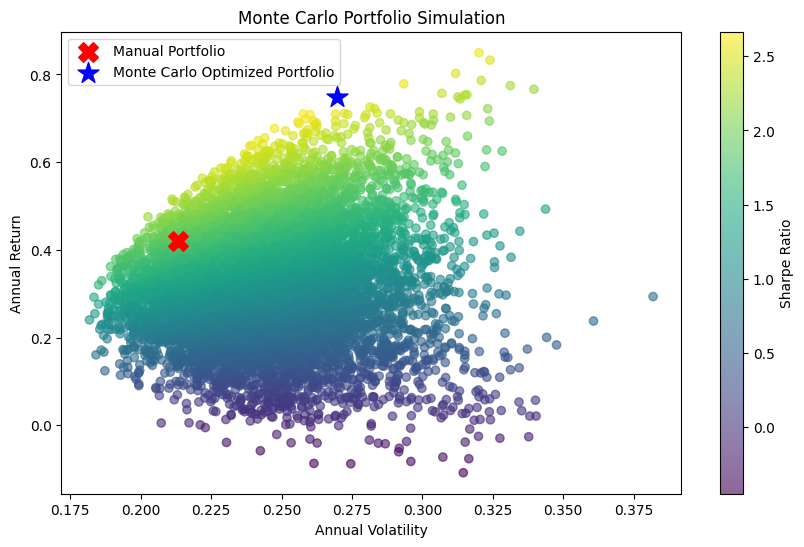

In [21]:
# ============================================================
# Zone 17: Plot Monte Carlo risk and return
# ============================================================

# Convert simulation results into a DataFrame
# This makes plotting easier
mc_results = pd.DataFrame({
    "Annual Return": mc_returns_list,
    "Annual Volatility": mc_volatility_list,
    "Sharpe Ratio": mc_sharpe_list,
    "Portfolio Beta": mc_beta_list
})

# Plot all simulated portfolios
# Each dot is one random portfolio
plt.figure(figsize=(10, 6))
plt.scatter(
    mc_results["Annual Volatility"],
    mc_results["Annual Return"],
    c=mc_results["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6
)

# Add colour bar
# The colour shows the Sharpe ratio of each portfolio
plt.colorbar(label="Sharpe Ratio")

# Plot the manual portfolio
# This shows where your own allocation sits compared with the simulated portfolios
plt.scatter(
    annual_volatility,
    annual_return,
    marker="X",
    s=200,
    color="red",
    label="Manual Portfolio"
)

# Plot the best Monte Carlo portfolio
# This is the portfolio with the highest Sharpe ratio
plt.scatter(
    best_volatility,
    best_return,
    marker="*",
    s=250,
    color="blue",
    label="Monte Carlo Optimized Portfolio"
)

plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.legend()
plt.show()


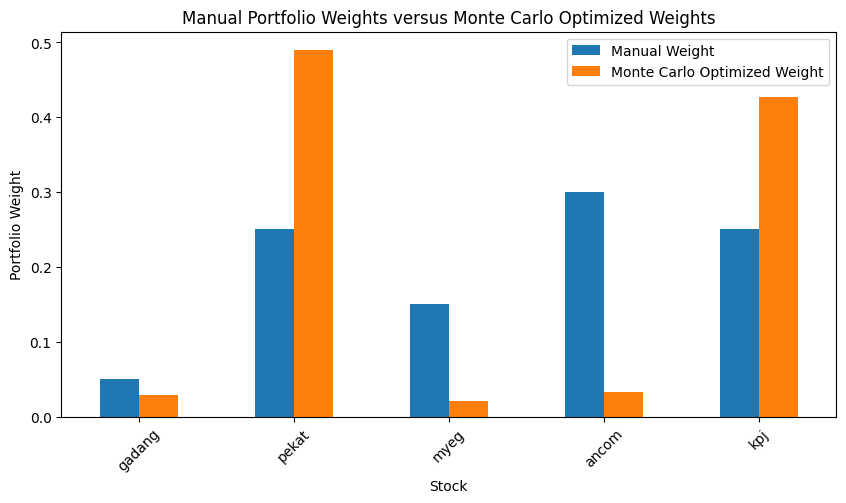

In [22]:
# ============================================================
# Zone 18: Plot manual weights versus optimized weights
# ============================================================

# Set stock names as index so the bar chart is easier to read
weight_plot = weight_comparison.set_index("Stock")

# Plot manual and optimized weights side by side
# This helps students see how portfolio allocation changed after optimization
weight_plot.plot(kind="bar", figsize=(10, 5))

plt.title("Manual Portfolio Weights versus Monte Carlo Optimized Weights")
plt.xlabel("Stock")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45)
plt.show()

### **References**

Academic Textbooks and Investment Literature
- Bodie, Z., Kane, A., & Marcus, A. J. (2018). *Investments* (11th ed.). McGraw-Hill Education.
- Reilly, F. K., & Brown, K. C. (2012). *Investment analysis and portfolio management* (10th ed.). Cengage Learning.
- CFA Institute. (2023). *CFA Program curriculum 2023 level III: Portfolio management and wealth planning*. CFA Institute.
- CFA Institute. (2023). *CFA Program curriculum 2023 level I: Quantitative methods and portfolio management*. CFA Institute.

Industry Practice and Professional Resources
- BlackRock. (2023). *Understanding portfolio risk and return: A guide to strategic asset allocation*. Retrieved from https://www.blackrock.com
- Vanguard Group. (2022). *How to build an investment portfolio.* Retrieved from https://www.vanguard.com
- Morningstar. (2021). *Asset allocation and portfolio construction.* Retrieved from https://www.morningstar.com
- Wealthfront. (2023). *Investment methodology white paper*. Retrieved from https://www.wealthfront.com/whitepaperskers  |
